# In-Code (Output-Time) PCA SED Coefficients — Verification & Comparison

This notebook:
1. Reads the PCA coefficients that L-GALAXIES writes **in-code at snapshot-output time** (`COMP_PCA_COEFFICIENTS`) from the binary output file. These are computed by convolving each galaxy's stored star-formation history with the PCA(age, Z) grid — the same code path as L-GALAXIES' post-processed magnitudes (`code/pca_sed.c` → `save.c`, next to `post_process_spec_mags`).
2. Reconstructs galaxy SEDs from these coefficients and computes synthetic SDSS *ugriz* AB magnitudes.
3. Compares the reconstructed magnitudes against:
   - L-GALAXIES stored `Mag` (intrinsic, from SSP tables)
   - Post-processing `synth_mag_*` from `lgalaxies_sed_coeffs_bc03.npz`
4. Provides an **interactive SED explorer** widget for any galaxy in the matched sample.

> **Terminology.** These 50 coefficients are a compact spectral *representation* computed at output time — **not** a live/wavelength-resolved SED carried as a state variable during the run, and not fed back into the physics. "On-the-fly" (used loosely in some labels below) means "computed by the code rather than loaded from a per-galaxy store." See `documents/onthefly_factcheck.md`.

**Pre-requisites (run once before this notebook):**
```bash
# 1. Export PCA grid for the C code
python scripts/export_pca_for_lgalaxies.py

# 2. Compile L-GALAXIES with PCA flag enabled
#    In My_Makefile_options: uncomment  OPT += -DCOMP_PCA_COEFFICIENTS
make clean && make

# 3. Run L-GALAXIES
./L-Galaxies ./input/input_MR_W1_PLANCK_LGals2020_DM.par

# 4. Run post-processing (for comparison)
python scripts/process_lgalaxies.py --backend bc03
```

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from pathlib import Path
from scipy import stats
import ipywidgets as widgets
from IPython.display import display

# ── Repo paths ─────────────────────────────────────────────────────────────
NOTEBOOK_DIR     = Path('.').resolve()
GALSPECTRA_ROOT  = NOTEBOOK_DIR.parent
LGAL_ROOT        = GALSPECTRA_ROOT.parent / 'L-GALAXIES' / 'LGalaxies2020_PublicRepository-master'
LGAL_PYTHON      = LGAL_ROOT / 'AuxCode' / 'Python'
FILTER_DIR       = LGAL_ROOT / 'SpecPhotTables' / 'Filters'

LGAL_OUTPUT_FILE = LGAL_ROOT / 'output' / 'SA_DM_test3_z0.00_5'
SAMPLE_FILE      = LGAL_ROOT / 'output' / 'samples' / \
                   'Planck_Mil-I_snapshots_default_test3_z0.00-0.00_All.npy'
POSTPROC_FILE    = GALSPECTRA_ROOT / 'data' / 'lgalaxies_sed_coeffs_bc03.npz'
PCA_FILE         = GALSPECTRA_ROOT / 'data' / 'pca_results_bc03.npz'

sys.path.insert(0, str(GALSPECTRA_ROOT / 'src'))
from galspectra.csp.reconstruct import reconstruction_sed_from_pca
from galspectra.photometry.filters import load_sdss_filters
from galspectra.photometry.synthetic import C_ANG_S

# ── Physical constants ─────────────────────────────────────────────────────
hub_h            = 0.673
DM_PART_MSUNh    = 0.0961104 * 1e10   # Mil-I DM particle mass [Msun/h]
PART_RES         = 20.0
SM_RES_MSUN      = 1e9                 # stellar mass cut [Msun]
_D_10PC_CM       = 3.0857e19           # 10 pc in cm
_FOUR_PI_10PC_SQ = 4.0 * np.pi * _D_10PC_CM**2

BANDS       = ['u', 'g', 'r', 'i', 'z']
BAND_IDX    = {b: i for i, b in enumerate(BANDS)}
BAND_COLORS = {'u': '#7B2FBE', 'g': '#4CAF50', 'r': '#F44336',
               'i': '#FF9800', 'z': '#795548'}
BAND_LEFF   = {'u': 3551, 'g': 4686, 'r': 6165, 'i': 7481, 'z': 8931}   # Å

print(f'L-GALAXIES root : {LGAL_ROOT}')
print(f'GALsPeCtrA root : {GALSPECTRA_ROOT}')
for label, path in [('Binary output', LGAL_OUTPUT_FILE), ('Sample', SAMPLE_FILE),
                    ('Post-proc', POSTPROC_FILE), ('PCA model', PCA_FILE)]:
    status = '✓' if path.exists() else '✗  MISSING'
    print(f'  {label:<15} {status}  {path.name}')

L-GALAXIES root : /Users/suteepornz/Documents/Suttikoon/Research_Projects/L-GALAXIES/LGalaxies2020_PublicRepository-master
GALsPeCtrA root : /Users/suteepornz/Documents/Suttikoon/Research_Projects/GALsPeCtrA
  Binary output   ✓  SA_DM_test3_z0.00_5
  Sample          ✓  Planck_Mil-I_snapshots_default_test3_z0.00-0.00_All.npy
  Post-proc       ✓  lgalaxies_sed_coeffs_bc03.npz
  PCA model       ✓  pca_results_bc03.npz


## 1. Load PCA model data and SDSS filters

In [3]:
# ── PCA model ──────────────────────────────────────────────────────────────
pca          = np.load(PCA_FILE, allow_pickle=True)
pca_wave     = pca['wave']                # (831,) Å, 805–29950
pca_comps    = pca['components']          # (50, 831)  PCA eigenvectors
pca_mean     = pca['mean']                # (831,)     mean of normalised training SEDs
pca_variance = pca['variance']            # (50,)      variance explained per PC
norm_meta    = pca['norm'].item()         # dict: 'mean' (831,), 'std' (831,)
norm_mean    = norm_meta['mean']          # per-wavelength mean before PCA
norm_std     = norm_meta['std']           # per-wavelength std  before PCA
pca_cumvar   = np.cumsum(pca_variance)

N_PC   = pca_comps.shape[0]
N_WAVE = len(pca_wave)

print(f'PCA: {N_PC} components  |  wavelength grid: {N_WAVE} bins  '
      f'({pca_wave[0]:.0f}–{pca_wave[-1]:.0f} Å)')
print(f'Variance explained: PC1 = {pca_cumvar[0]*100:.1f}%  '
      f'PC10 = {pca_cumvar[9]*100:.2f}%  '
      f'PC50 = {pca_cumvar[-1]*100:.4f}%')

# ── SDSS filters ───────────────────────────────────────────────────────────
filters = load_sdss_filters(FILTER_DIR)
print(f'\nFilters loaded: {list(filters.keys())}')
for b, (wf, tf) in filters.items():
    print(f'  {b}: {wf[0]:.0f}–{wf[-1]:.0f} Å  ({len(wf)} points)')

PCA: 50 components  |  wavelength grid: 831 bins  (805–29950 Å)
Variance explained: PC1 = 68.2%  PC10 = 99.99%  PC50 = 100.0000%

Filters loaded: ['u', 'g', 'r', 'i', 'z']
  u: 2980–4130 Å  (47 points)
  g: 3630–5830 Å  (89 points)
  r: 5380–7230 Å  (75 points)
  i: 6430–8630 Å  (89 points)
  z: 7730–11230 Å  (141 points)


## 2. Load L-GALAXIES binary output (with on-the-fly PCA coefficients)

In [4]:
sys.path.insert(0, str(LGAL_PYTHON))
from LGalaxy_snapshots import LGalaxiesStruct

def load_lgal_binary(path):
    """Read L-GALAXIES binary snapshot, skipping the variable-length header.
    Header: [int32 Ntrees][int32 TotGals][int32×Ntrees per-tree counts][galaxies...]
    """
    with open(path, 'rb') as f:
        n_trees = np.fromfile(f, np.int32, 1)[0]
        n_gals  = np.fromfile(f, np.int32, 1)[0]
        _       = np.fromfile(f, np.int32, n_trees)   # per-tree galaxy counts
        data    = np.fromfile(f, dtype=LGalaxiesStruct, count=n_gals)
    return data, n_trees, n_gals

print(f'Reading {LGAL_OUTPUT_FILE.name}  ({LGAL_OUTPUT_FILE.stat().st_size/1e6:.0f} MB)...')
gals_all, n_trees, n_gals = load_lgal_binary(LGAL_OUTPUT_FILE)
print(f'  {n_gals:,} galaxies in {n_trees} trees  |  struct size = {LGalaxiesStruct.itemsize} B/galaxy')

# Check pca_coeffs field is present and non-zero
n_nonzero = np.sum(np.any(gals_all['pca_coeffs'] != 0, axis=1))
print(f'  Galaxies with non-zero pca_coeffs: {n_nonzero:,} / {n_gals:,}')

# ── Apply selection cuts (same as process_lgalaxies.py) ───────────────────
mvir_ok = gals_all['Mvir'].astype(np.float64) * 1e10 >= DM_PART_MSUNh * PART_RES
sm_ok   = gals_all['StellarMass'].astype(np.float64) * 1e10 / hub_h >= SM_RES_MSUN
sel     = mvir_ok & sm_ok
gals    = gals_all[sel]

print(f'\nAfter selection cuts ({SM_RES_MSUN:.0e} Msun, Mvir >= {DM_PART_MSUNh*PART_RES:.2e} Msun/h):')
print(f'  {len(gals):,} galaxies selected')
print(f'  pca_coeffs dtype: {gals["pca_coeffs"].dtype}  '
      f'shape: {gals["pca_coeffs"].shape}')

Reading SA_DM_test3_z0.00_5  (258 MB)...
  29,291 galaxies in 28987 trees  |  struct size = 8792 B/galaxy
  Galaxies with non-zero pca_coeffs: 29,291 / 29,291

After selection cuts (1e+09 Msun, Mvir >= 1.92e+10 Msun/h):
  11,327 galaxies selected
  pca_coeffs dtype: float32  shape: (11327, 50)


## 3. Load sample .npy and post-processing data

In [5]:
sample = np.load(SAMPLE_FILE, allow_pickle=True)
print(f'Sample: {len(sample):,} galaxies')
print(f'  Fields: {sample.dtype.names[:8]}...')

# Post-processing data
pp       = np.load(POSTPROC_FILE, allow_pickle=True)
pp_coeffs = pp['pca_coeffs'].astype(np.float64)   # (11328, 50)
pp_gidx  = pp['galaxy_index']                      # indices into sample
print(f'\nPost-processing: {len(pp_coeffs):,} galaxies')
print(f'  galaxy_index range: {pp_gidx.min()}–{pp_gidx.max()}  '
      f'(sequential: {np.all(np.diff(pp_gidx) == 1)})')
print(f'  Available synth mags: {[k for k in pp.keys() if "synth" in k]}')

Sample: 11,328 galaxies
  Fields: ('Type', 'HaloIndex', 'HaloM_Mean200', 'HaloM_Crit200', 'HaloM_TopHat', 'HaloPos', 'HaloVel', 'HaloVelDisp')...

Post-processing: 11,328 galaxies
  galaxy_index range: 0–11327  (sequential: True)
  Available synth mags: ['synth_mag_u', 'synth_mag_g', 'synth_mag_r', 'synth_mag_i', 'synth_mag_z', 'synth_magdust_u', 'synth_magdust_g', 'synth_magdust_r', 'synth_magdust_i', 'synth_magdust_z']


## 4. Match binary galaxies to sample

Both the binary selection and the sample come from the same model run, so galaxies appear in the same order.  A two-pointer scan with one-step lookahead handles the ±1 galaxy that can appear at the `Mvir` floating-point boundary.

In [6]:
SM_TOL = 1e-5   # relative tolerance on StellarMass float32 round-trip

def sm_match(i_bin, j_sam):
    sm_b = float(gals[i_bin]['StellarMass'])
    sm_s = float(sample[j_sam]['StellarMass']) * hub_h / 1e10
    return abs(sm_b - sm_s) / (sm_b + 1e-30) < SM_TOL

matched_i = []   # indices into gals (binary, after selection)
matched_j = []   # indices into sample

i = 0; j = 0
while i < len(gals) and j < len(sample):
    if sm_match(i, j):
        matched_i.append(i)
        matched_j.append(j)
        i += 1; j += 1
    elif j + 1 < len(sample) and sm_match(i, j + 1):
        j += 1          # extra entry in sample; skip it
    elif i + 1 < len(gals) and sm_match(i + 1, j):
        i += 1          # extra entry in binary; skip it
    else:
        i += 1; j += 1  # genuine gap; skip both

matched_i = np.array(matched_i)
matched_j = np.array(matched_j)
N_MATCH   = len(matched_i)

print(f'Matched: {N_MATCH:,}  |  unmatched in sample: {len(sample) - N_MATCH}')
if N_MATCH < 100:
    print('WARNING: very few matches — check input files.')

# Slice matched arrays
gals_m   = gals[matched_i]      # matched binary galaxies
sample_m = sample[matched_j]    # matched sample galaxies

# Align post-processing data with the matched sample
# pp_gidx maps pp rows to sample indices; invert it
pp_order = np.searchsorted(pp_gidx, matched_j)
# Verify alignment
assert np.all(pp_gidx[pp_order] == matched_j), 'Post-processing alignment failed!'
pp_coeffs_m = pp_coeffs[pp_order]   # (N_MATCH, 50)

# Post-processing synthetic magnitudes for matched galaxies
pp_synth_m     = {b: pp[f'synth_mag_{b}'][pp_order]     for b in BANDS}
pp_synthdust_m = {b: pp[f'synth_magdust_{b}'][pp_order] for b in BANDS}
print(f'Post-processing data aligned: {len(pp_coeffs_m):,} galaxies')

Matched: 11,327  |  unmatched in sample: 1
Post-processing data aligned: 11,327 galaxies


## 5. Compute total SFH mass and reconstruct SEDs

**Reconstruction formula (vectorised over all galaxies):**
1. $M_\mathrm{tot} = \sum_{\ell=0}^{\mathrm{sfh\_ibin}} (m_\mathrm{disk}[\ell] + m_\mathrm{bulge}[\ell])\;\times\;10^{10}/h$ [M☉]
2. Normalised coefficients: $\tilde{\mathbf{c}} = \mathbf{c}_\mathrm{otf} / M_\mathrm{tot}$
3. Normalised SED per M☉: $\tilde{f}_\lambda = \bar{\mu} + \tilde{\mathbf{c}}\,\mathbf{P}$ where $\mathbf{P}$ = PCA eigenvectors
4. Denormalise: $f_\lambda^\mathrm{per\ M_\odot} = \tilde{f}_\lambda\cdot\sigma_\lambda + \mu_\lambda$
5. Scale to 10 pc: $f_\lambda = f_\lambda^\mathrm{per\ M_\odot}\cdot M_\mathrm{tot} / (4\pi\, d_{10}^2)$ [erg/s/Å/cm²]

In [7]:
# ── Total SFH mass per galaxy (vectorised) ─────────────────────────────────
sfh_ibin   = gals_m['sfh_ibin'].astype(int)        # (N,)
n_sfh_bins = gals_m['sfh_DiskMass'].shape[1]        # 20
bin_range  = np.arange(n_sfh_bins)[np.newaxis, :]  # (1, 20)
sfh_mask   = bin_range <= sfh_ibin[:, np.newaxis]   # (N, 20)  valid bins

M_disk_raw  = (gals_m['sfh_DiskMass']  * sfh_mask).sum(axis=1)   # (N,) 10^10 Msun/h
M_bulge_raw = (gals_m['sfh_BulgeMass'] * sfh_mask).sum(axis=1)   # (N,) 10^10 Msun/h
M_total     = (M_disk_raw + M_bulge_raw).astype(np.float64) * 1e10 / hub_h   # (N,) Msun

print(f'M_total range: {M_total.min():.2e} – {M_total.max():.2e} Msun')
print(f'  Median M_total = {np.median(M_total):.2e} Msun')

# ── Vectorised SED reconstruction ─────────────────────────────────────────
otf_coeffs  = gals_m['pca_coeffs'].astype(np.float64)   # (N, 50)

# Guard against zero mass (should not occur after selection, but just in case)
good        = M_total > 0
norm_c      = np.zeros_like(otf_coeffs)               # (N, 50)
norm_c[good] = otf_coeffs[good] / M_total[good, np.newaxis]

# sed_norm[i] = pca_mean + norm_c[i] @ pca_comps  (in normalised space)
sed_norm    = pca_mean[np.newaxis, :] + norm_c @ pca_comps   # (N, 831)

# Denormalise: f_per_msun[i, λ] = sed_norm[i, λ] * norm_std[λ] + norm_mean[λ]
sed_per_msun = sed_norm * norm_std[np.newaxis, :] + norm_mean[np.newaxis, :]   # (N, 831)

# Scale to absolute flux at 10 pc
seds        = sed_per_msun * M_total[:, np.newaxis] / _FOUR_PI_10PC_SQ   # (N, 831)

print(f'\nReconstructed {len(seds):,} SEDs  (shape {seds.shape})')
print(f'  Flux range at 5000 Å: {seds[:, np.argmin(np.abs(pca_wave - 5000))].min():.2e} – '
      f'{seds[:, np.argmin(np.abs(pca_wave - 5000))].max():.2e} erg/s/Å/cm²')

M_total range: 1.47e+09 – 8.92e+11 Msun
  Median M_total = 6.39e+09 Msun

Reconstructed 11,327 SEDs  (shape (11327, 831))
  Flux range at 5000 Å: 1.46e-02 – 1.23e+01 erg/s/Å/cm²


## 6. Compute synthetic AB magnitudes (batch)

Integrates each SED against the SDSS filter curves using the standard AB formula:
$$m_\mathrm{AB} = -2.5\log_{10}\!\left(\frac{\int f_\nu\, T_\nu\, d\nu}{\int T_\nu\, d\nu}\right) - 48.6$$

In [8]:
def compute_ab_mag_batch(wave, seds_flam, filters):
    """Vectorised AB magnitudes.  seds_flam: (N, N_wave) in erg/s/Å/cm²."""
    nu_hz = C_ANG_S / wave            # (N_wave,) descending
    idx   = np.argsort(nu_hz)         # ascending frequency order
    nu_s  = nu_hz[idx]                # (N_wave,)
    # f_ν = f_λ * λ² / c
    fnu   = seds_flam * (wave**2 / C_ANG_S)[np.newaxis, :]   # (N, N_wave)
    fnu_s = fnu[:, idx]               # (N, N_wave) in ascending ν order

    mags = {}
    for name, (wf, tf) in filters.items():
        T     = np.interp(wave, wf, tf, left=0., right=0.)[idx]  # (N_wave,)
        if T.sum() == 0:
            mags[name] = np.full(len(seds_flam), np.nan)
            continue
        num   = np.trapezoid(fnu_s * T[np.newaxis, :], nu_s, axis=1)  # (N,)
        den   = float(np.trapezoid(T, nu_s))
        with np.errstate(divide='ignore', invalid='ignore'):
            mags[name] = np.where(num > 0,
                                  -2.5 * np.log10(num / den) - 48.6,
                                  np.nan)
    return mags

print('Computing synthetic magnitudes for all matched galaxies...')
synth_mags = compute_ab_mag_batch(pca_wave, seds, filters)  # dict {band: (N,)}

for b in BANDS:
    valid = np.isfinite(synth_mags[b])
    print(f'  {b}: {valid.sum():,} finite   '
          f'median = {np.nanmedian(synth_mags[b]):.2f} mag')

Computing synthetic magnitudes for all matched galaxies...
  u: 11,327 finite   median = -17.67 mag
  g: 11,327 finite   median = -18.78 mag
  r: 11,327 finite   median = -19.23 mag
  i: 11,327 finite   median = -19.44 mag
  z: 11,327 finite   median = -19.62 mag


## 7. On-the-fly synthetic mags vs L-GALAXIES intrinsic `Mag`

`Mag` from L-GALAXIES is computed by the SSP spectral synthesis (`post_process_spec_mags`).
The PCA reconstruction should reproduce these to within ≲ 0.05 mag.

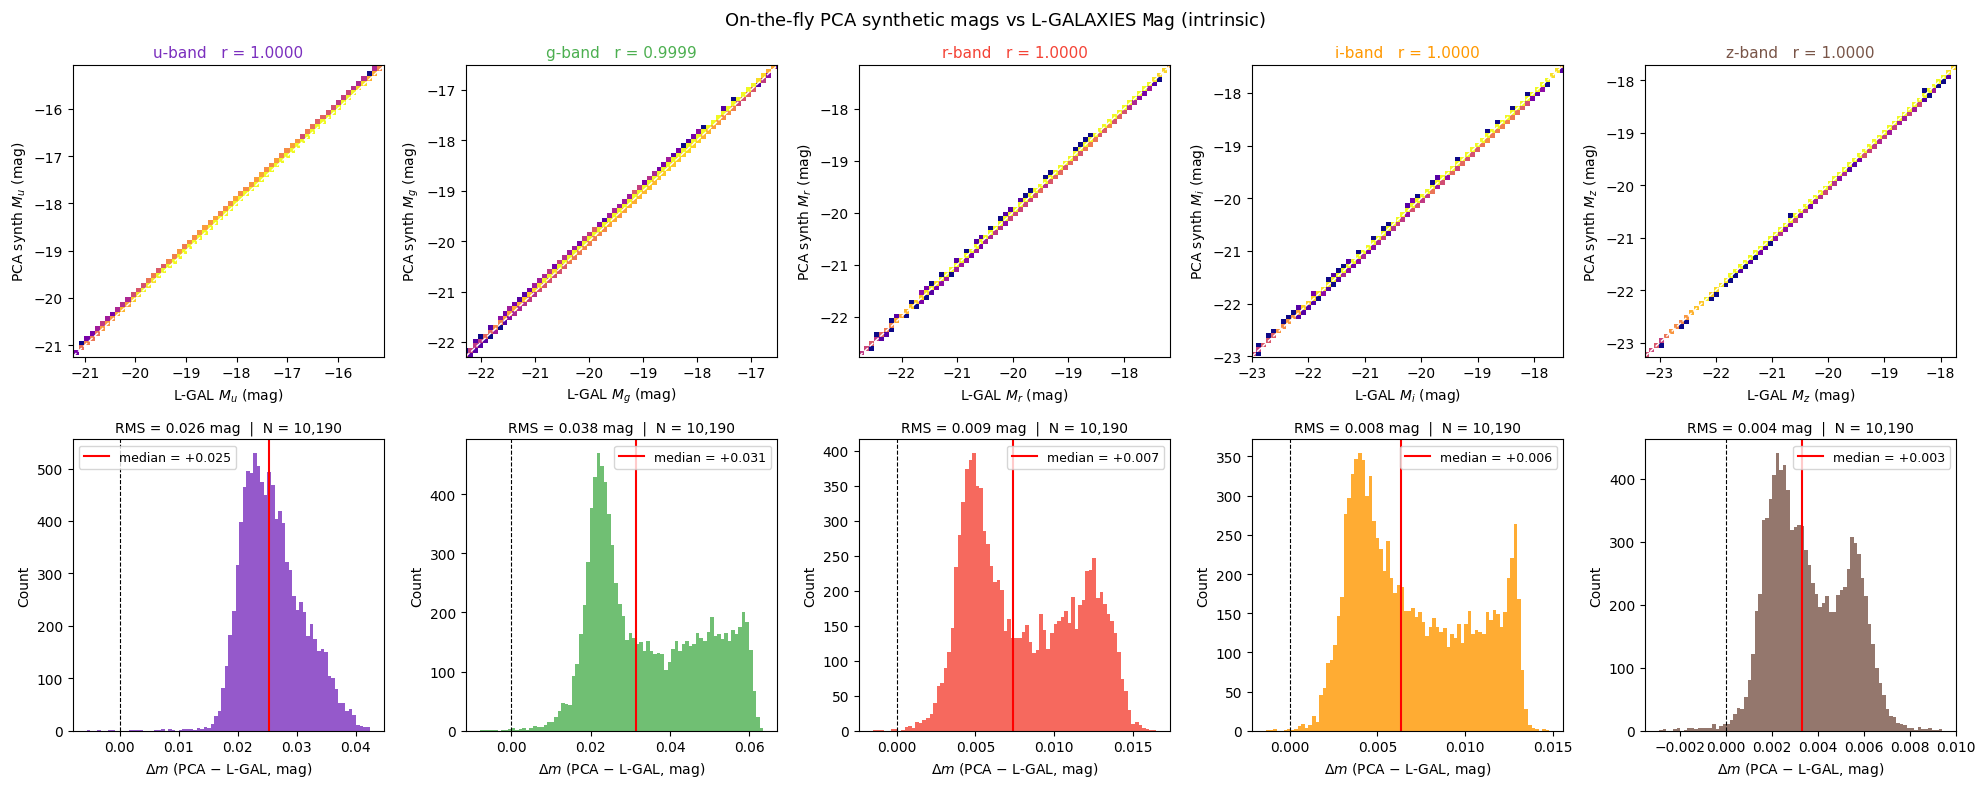

In [9]:
lgal_mag  = sample_m['Mag']      # (N, 5) intrinsic SDSS ugriz, absolute AB mag

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('On-the-fly PCA synthetic mags vs L-GALAXIES $\\mathtt{Mag}$ (intrinsic)',
             fontsize=13)

for col, b in enumerate(BANDS):
    bi     = BAND_IDX[b]
    synth  = synth_mags[b]
    stored = lgal_mag[:, bi]
    valid  = np.isfinite(synth) & (stored < 90.0)
    x, y   = synth[valid], stored[valid]
    delta  = x - y

    # ── scatter ───────────────────────────────────────────────────────────
    ax = axes[0, col]
    ax.hist2d(y, x, bins=80, cmin=1, cmap='plasma',
              norm=LogNorm(vmin=1, vmax=max(10, len(x)//100)))
    xlim = (np.percentile(y, 0.5), np.percentile(y, 99.5))
    ax.plot(xlim, xlim, 'w--', lw=1.0, label='1:1')
    ax.set_xlim(*xlim); ax.set_ylim(*xlim)
    ax.set_xlabel(f'L-GAL $M_{b}$ (mag)', fontsize=10)
    ax.set_ylabel(f'PCA synth $M_{b}$ (mag)', fontsize=10)
    r, _ = stats.pearsonr(x, y)
    ax.set_title(f'{b}-band   r = {r:.4f}', color=BAND_COLORS[b], fontsize=11)

    # ── residual histogram ─────────────────────────────────────────────────
    ax2 = axes[1, col]
    ax2.hist(delta, bins=80, color=BAND_COLORS[b], alpha=0.8, edgecolor='none')
    ax2.axvline(0, color='k', lw=0.8, ls='--')
    ax2.axvline(np.median(delta), color='red', lw=1.5,
                label=f'median = {np.median(delta):+.3f}')
    ax2.set_xlabel(r'$\Delta m$ (PCA $-$ L-GAL, mag)', fontsize=10)
    ax2.set_ylabel('Count', fontsize=10)
    ax2.legend(fontsize=9)
    rms = np.sqrt(np.mean(delta**2))
    ax2.set_title(f'RMS = {rms:.3f} mag  |  N = {valid.sum():,}', fontsize=10)

plt.tight_layout()
plt.savefig(GALSPECTRA_ROOT / 'data' / 'pca_otf_vs_lgal_intrinsic.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 8. On-the-fly mags vs post-processing `synth_mag_*`

Both use the same PCA model and the same galaxy SFH data, so the agreement should be
near-perfect (differences arise only from float32 → float64 rounding in the C code).

<>:2: SyntaxWarning: invalid escape sequence '\_'
<>:2: SyntaxWarning: invalid escape sequence '\_'
/var/folders/6s/y01rl1q51659nl7xcmnpnwv80000gn/T/ipykernel_45548/277033031.py:2: SyntaxWarning: invalid escape sequence '\_'
  fig.suptitle('On-the-fly PCA synthetic mags vs post-processing $\\mathtt{synth\_mag}$',


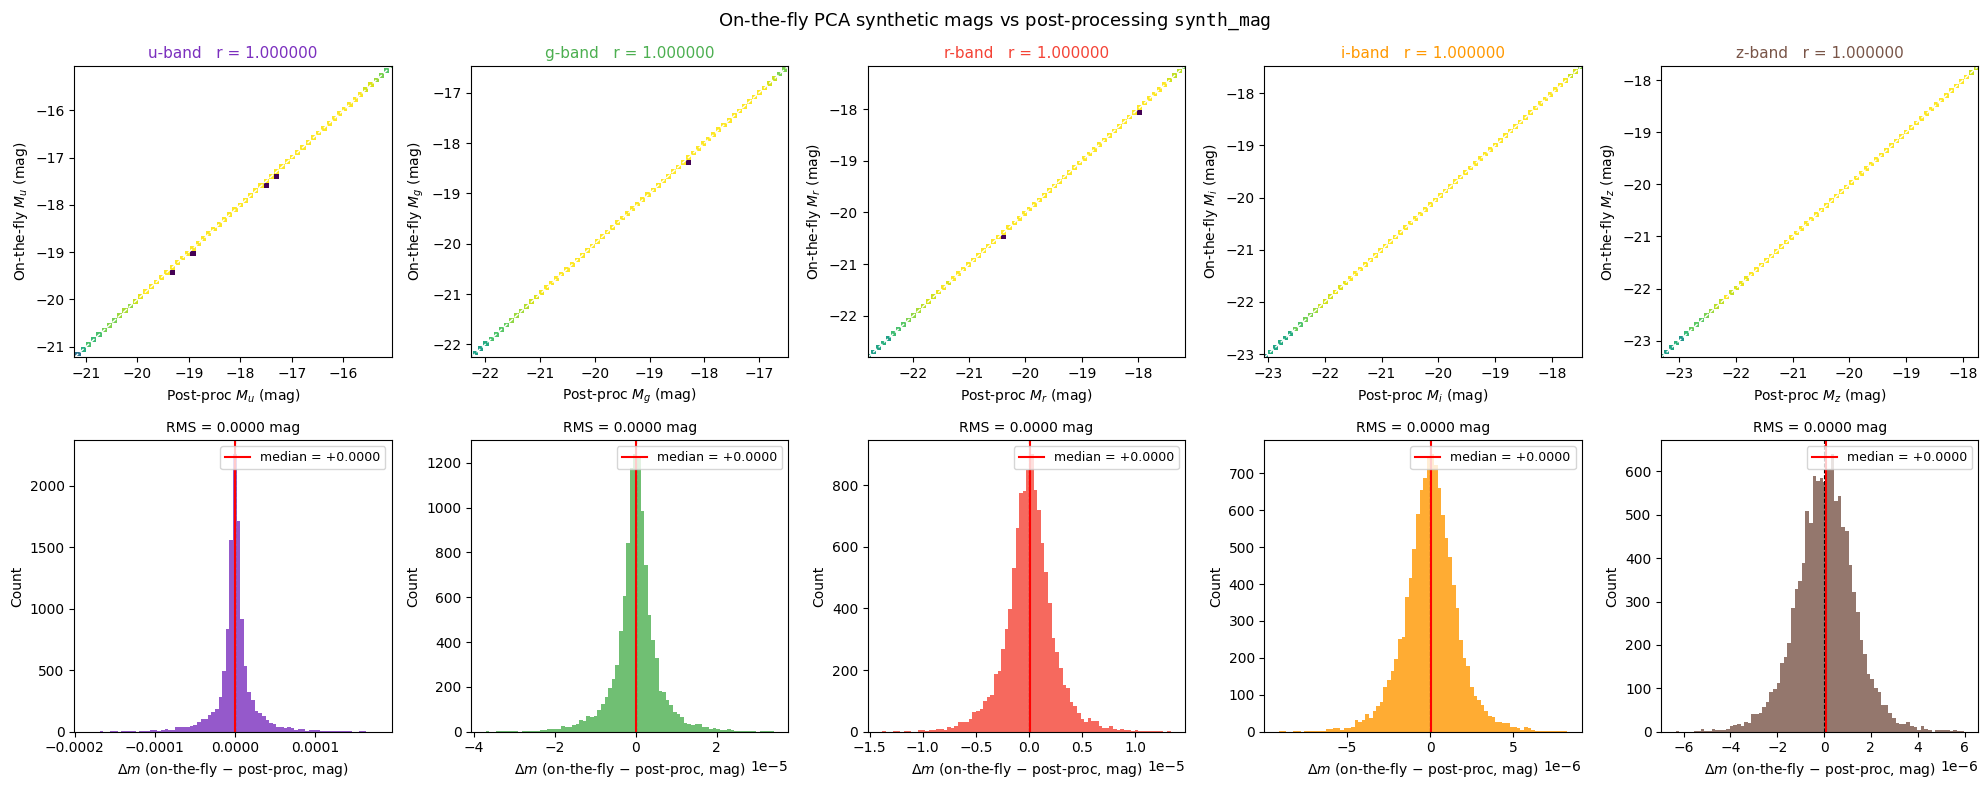

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('On-the-fly PCA synthetic mags vs post-processing $\\mathtt{synth\_mag}$',
             fontsize=13)

for col, b in enumerate(BANDS):
    synth  = synth_mags[b]
    stored = pp_synth_m[b]
    valid  = np.isfinite(synth) & np.isfinite(stored) & (stored < 90.0)
    x, y   = synth[valid], stored[valid]
    delta  = x - y

    ax = axes[0, col]
    ax.hist2d(y, x, bins=80, cmin=1, cmap='viridis',
              norm=LogNorm(vmin=1, vmax=max(10, len(x)//100)))
    xlim = (np.percentile(y, 0.5), np.percentile(y, 99.5))
    ax.plot(xlim, xlim, 'w--', lw=1.0)
    ax.set_xlim(*xlim); ax.set_ylim(*xlim)
    ax.set_xlabel(f'Post-proc $M_{b}$ (mag)', fontsize=10)
    ax.set_ylabel(f'On-the-fly $M_{b}$ (mag)', fontsize=10)
    r, _ = stats.pearsonr(x, y)
    ax.set_title(f'{b}-band   r = {r:.6f}', color=BAND_COLORS[b], fontsize=11)

    ax2 = axes[1, col]
    ax2.hist(delta, bins=80, color=BAND_COLORS[b], alpha=0.8, edgecolor='none')
    ax2.axvline(0, color='k', lw=0.8, ls='--')
    ax2.axvline(np.median(delta), color='red', lw=1.5,
                label=f'median = {np.median(delta):+.4f}')
    ax2.set_xlabel(r'$\Delta m$ (on-the-fly $-$ post-proc, mag)', fontsize=10)
    ax2.set_ylabel('Count', fontsize=10)
    ax2.legend(fontsize=9)
    rms = np.sqrt(np.mean(delta**2))
    ax2.set_title(f'RMS = {rms:.4f} mag', fontsize=10)

plt.tight_layout()
plt.savefig(GALSPECTRA_ROOT / 'data' / 'pca_otf_vs_postproc.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary statistics

In [11]:
print(f'{"Band":<6}  {"":=<58}')
print(f'{"Band":<6}  {"On-the-fly vs L-GAL Mag":^28}  {"On-the-fly vs post-proc":^28}')
print(f'{"":<6}  {"median Δ":>10} {"RMS":>8} {"r":>8}  {"median Δ":>10} {"RMS":>8} {"r":>8}')
print(f'{"":<6}  {"-"*28}  {"-"*28}')

for b in BANDS:
    bi       = BAND_IDX[b]
    synth    = synth_mags[b]
    lgal     = sample_m['Mag'][:, bi]
    pp_s     = pp_synth_m[b]

    vl = np.isfinite(synth) & (lgal < 90.0)
    vp = np.isfinite(synth) & np.isfinite(pp_s)

    dl  = synth[vl] - lgal[vl]
    dp  = synth[vp] - pp_s[vp]
    r_l, _ = stats.pearsonr(synth[vl], lgal[vl])
    r_p, _ = stats.pearsonr(synth[vp], pp_s[vp])

    print(f'{b:<6}  {np.median(dl):>+10.3f} {np.sqrt(np.mean(dl**2)):>8.3f} {r_l:>8.4f}  '
          f'{np.median(dp):>+10.4f} {np.sqrt(np.mean(dp**2)):>8.4f} {r_p:>8.6f}')

print(f'{"":<6}  {"":-<58}')
print('\nNotes:')
print('  vs L-GAL Mag: residuals reflect PCA reconstruction accuracy + filter differences')
print('  vs post-proc: near-zero means C on-the-fly = Python post-processing (numerical validation)')

Band    ==========================================================
Band      On-the-fly vs L-GAL Mag       On-the-fly vs post-proc   
          median Δ      RMS        r    median Δ      RMS        r
        ----------------------------  ----------------------------
u           +0.025    0.026   1.0000     +0.0000   0.0000 1.000000
g           +0.031    0.038   0.9999     +0.0000   0.0000 1.000000
r           +0.007    0.009   1.0000     +0.0000   0.0000 1.000000
i           +0.006    0.008   1.0000     +0.0000   0.0000 1.000000
z           +0.003    0.004   1.0000     +0.0000   0.0000 1.000000
        ----------------------------------------------------------

Notes:
  vs L-GAL Mag: residuals reflect PCA reconstruction accuracy + filter differences
  vs post-proc: near-zero means C on-the-fly = Python post-processing (numerical validation)


## 10. Colour–magnitude and colour–colour diagnostics

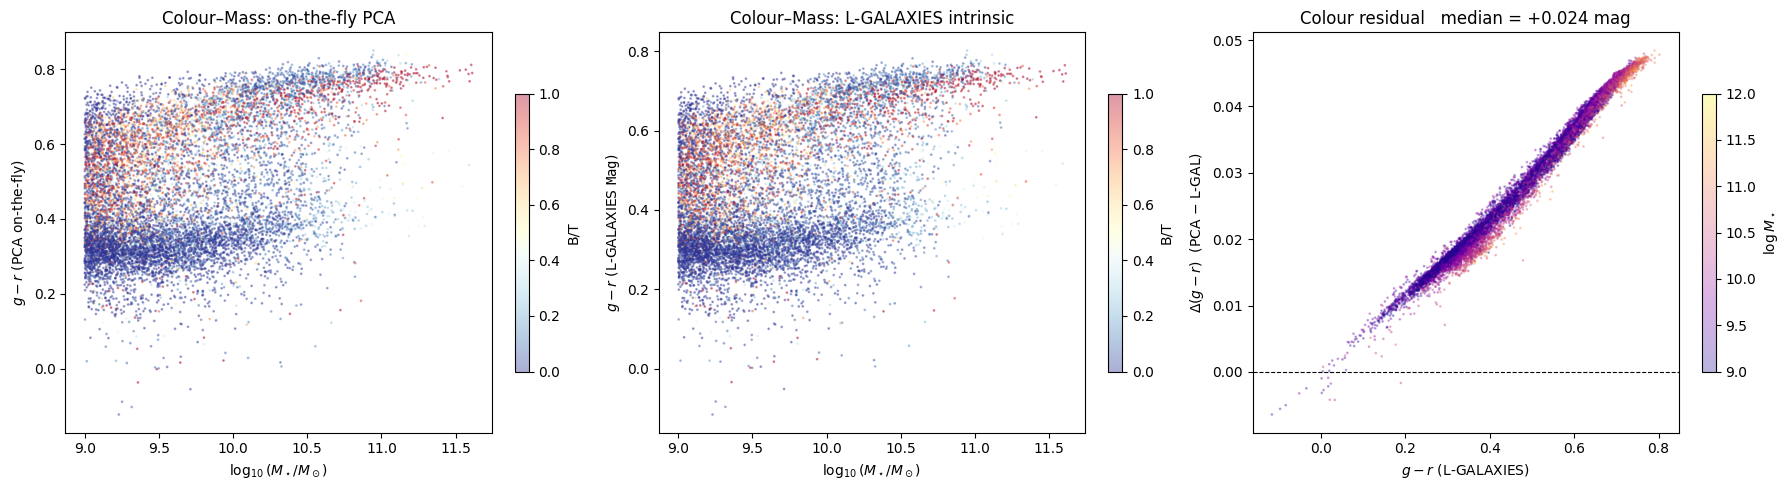

In [12]:
# Derive galaxy properties from sample
log_mstar = np.log10(sample_m['StellarMass'] + 1e-10)   # Msun
bt        = sample_m['BulgeMass'] / (sample_m['StellarMass'] + 1e-10)

# Colours from on-the-fly synthetic mags
gr_otf   = synth_mags['g'] - synth_mags['r']
ur_otf   = synth_mags['u'] - synth_mags['r']

# Colours from L-GALAXIES stored Mag
lgal_mag = sample_m['Mag']
gr_lgal  = lgal_mag[:, 1] - lgal_mag[:, 2]
ur_lgal  = lgal_mag[:, 0] - lgal_mag[:, 2]

valid_both = np.isfinite(gr_otf) & (lgal_mag[:, 2] < 90.)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── CMD: PCA ──────────────────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(log_mstar[valid_both], gr_otf[valid_both],
                c=bt[valid_both], cmap='RdYlBu_r', s=1, alpha=0.4, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='B/T', fraction=0.03)
ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$')
ax.set_ylabel(r'$g - r$ (PCA on-the-fly)')
ax.set_title('Colour–Mass: on-the-fly PCA')

# ── CMD: L-GALAXIES ───────────────────────────────────────────────────────
ax = axes[1]
sc = ax.scatter(log_mstar[valid_both], gr_lgal[valid_both],
                c=bt[valid_both], cmap='RdYlBu_r', s=1, alpha=0.4, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='B/T', fraction=0.03)
ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$')
ax.set_ylabel(r'$g - r$ (L-GALAXIES $\mathtt{Mag}$)')
ax.set_title('Colour–Mass: L-GALAXIES intrinsic')

# ── Colour residual vs colour ─────────────────────────────────────────────
ax = axes[2]
d_gr = gr_otf[valid_both] - gr_lgal[valid_both]
sc = ax.scatter(gr_lgal[valid_both], d_gr,
                c=log_mstar[valid_both], cmap='plasma', s=1, alpha=0.3,
                vmin=9, vmax=12)
plt.colorbar(sc, ax=ax, label=r'$\log M_\star$', fraction=0.03)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel(r'$g - r$ (L-GALAXIES)')
ax.set_ylabel(r'$\Delta(g-r)$  (PCA $-$ L-GAL)')
ax.set_title(f'Colour residual   median = {np.median(d_gr):+.3f} mag')

plt.tight_layout()
plt.show()

## 11. Interactive SED explorer

Select any galaxy from the matched sample.  The plot shows:
- **Black solid line** — SED reconstructed from the on-the-fly PCA coefficients
- **Shaded regions** — SDSS *ugriz* filter bandpasses (scaled for visibility)
- **Markers** — synthetic AB magnitudes (on-the-fly ✦) and L-GALAXIES stored `Mag` (◆)

> **Tip:** A slider value of 0 is the first matched galaxy; use the galaxy properties panel to find interesting objects.

In [13]:
from ipywidgets import interact, IntSlider, Checkbox, Layout

def plot_galaxy_sed(galaxy_idx=0, log_scale=True, show_residuals=True):
    """Plot on-the-fly reconstructed SED for the given galaxy index."""
    k    = galaxy_idx
    sed  = seds[k]                                     # (N_WAVE,) erg/s/Å/cm²
    sam  = sample_m[k]

    # Galaxy properties
    log_m  = float(np.log10(sam['StellarMass'] + 1e-30))
    sfr    = float(sam['Sfr'])
    bt_val = float(sam['BulgeMass'] / (sam['StellarMass'] + 1e-10))
    gr_val = float(synth_mags['g'][k] - synth_mags['r'][k])

    # Synthetic mags from on-the-fly (already computed)
    otf_m  = {b: float(synth_mags[b][k]) for b in BANDS}
    lgal_m = {b: float(sam['Mag'][BAND_IDX[b]]) for b in BANDS}
    pp_m   = {b: float(pp_synth_m[b][k]) for b in BANDS}

    # ── Layout ────────────────────────────────────────────────────────────
    if show_residuals:
        fig = plt.figure(figsize=(16, 6))
        gs  = gridspec.GridSpec(1, 2, width_ratios=[2, 1])
        ax_sed = fig.add_subplot(gs[0])
        ax_res = fig.add_subplot(gs[1])
    else:
        fig, ax_sed = plt.subplots(figsize=(11, 6))
        ax_res = None

    # ── SED panel ─────────────────────────────────────────────────────────
    if log_scale:
        sed_plot = np.maximum(sed, 1e-40)
        ax_sed.semilogy(pca_wave, sed_plot, color='black', lw=2.0,
                        label='On-the-fly PCA SED', zorder=5)
        sed_peak = sed_plot.max()
    else:
        ax_sed.plot(pca_wave, sed, color='black', lw=2.0,
                    label='On-the-fly PCA SED', zorder=5)
        sed_peak = sed.max()

    # Filter bandpasses (shaded) + band labels
    for band, (wf, tf) in filters.items():
        tf_interp = np.interp(pca_wave, wf, tf, left=0., right=0.)
        peak_idx  = int(np.argmax(tf_interp))
        scale     = sed_peak * 0.20
        if log_scale:
            ax_sed.fill_between(pca_wave, 1e-40,
                                np.maximum(tf_interp * scale, 1e-40),
                                alpha=0.12, color=BAND_COLORS[band])
        else:
            ax_sed.fill_between(pca_wave, 0, tf_interp * scale,
                                alpha=0.12, color=BAND_COLORS[band])
        ax_sed.text(pca_wave[peak_idx], tf_interp[peak_idx] * scale * 1.05,
                    band, ha='center', va='bottom',
                    fontsize=9, color=BAND_COLORS[band], fontweight='bold')

    # Synthetic magnitude markers at filter effective wavelengths
    for band in BANDS:
        leff  = BAND_LEFF[band]
        f_ref = float(np.interp(leff, pca_wave, sed))
        if f_ref > 0 and np.isfinite(otf_m[band]):
            ax_sed.scatter([leff], [f_ref], marker='*', s=150,
                           color=BAND_COLORS[band], zorder=8)

    ax_sed.set_xlim(pca_wave[0], pca_wave[-1])
    ax_sed.set_xlabel('Wavelength (Å)', fontsize=12)
    ax_sed.set_ylabel(r'$f_\lambda$  (erg s$^{-1}$ Å$^{-1}$ cm$^{-2}$)', fontsize=12)
    ax_sed.set_title(
        f'Galaxy #{k}  |  '
        f'$\\log M_\\star = {log_m:.2f}$  |  '
        f'$g-r = {gr_val:.3f}$  |  '
        f'$B/T = {bt_val:.2f}$  |  '
        f'SFR = {sfr:.2f} M☉/yr',
        fontsize=11)
    ax_sed.legend(fontsize=10, loc='upper right')

    # ── Residual bar chart ─────────────────────────────────────────────────
    if ax_res is not None:
        x      = np.arange(len(BANDS))
        w      = 0.35
        d_lgal = [otf_m[b] - lgal_m[b] if lgal_m[b] < 90. else 0. for b in BANDS]
        d_pp   = [otf_m[b] - pp_m[b]   if np.isfinite(pp_m[b]) else 0. for b in BANDS]

        ax_res.bar(x - w/2, d_lgal, w, color='steelblue', alpha=0.85,
                   label='OTF − L-GAL Mag')
        ax_res.bar(x + w/2, d_pp,   w, color='tomato',    alpha=0.85,
                   label='OTF − post-proc')
        ax_res.axhline(0, color='k', lw=0.8)
        ax_res.set_xticks(x)
        ax_res.set_xticklabels(BANDS, fontsize=11)
        ax_res.set_xlabel('SDSS band', fontsize=11)
        ax_res.set_ylabel(r'$\Delta m$ (mag)', fontsize=11)
        ax_res.set_ylim(-0.5, 0.5)
        ax_res.set_title('Magnitude residuals', fontsize=11)
        ax_res.legend(fontsize=9)
        ax_res.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Magnitude table (printed below figure) ────────────────────────────
    print(f'{"Band":<5} {"OTF":>8} {"L-GAL Mag":>10} {"Δ(OTF-LG)":>10} | '
          f'{"post-proc":>10} {"Δ(OTF-PP)":>10}')
    print('─' * 62)
    for b in BANDS:
        lgal_str = f'{lgal_m[b]:>10.3f}' if lgal_m[b] < 90. else f'{"(n/a)":>10}'
        dlg_str  = f'{otf_m[b]-lgal_m[b]:>+10.3f}' if lgal_m[b] < 90. else f'{"--":>10}'
        pp_str   = f'{pp_m[b]:>10.3f}' if np.isfinite(pp_m[b]) else f'{"(n/a)":>10}'
        dpp_str  = f'{otf_m[b]-pp_m[b]:>+10.4f}' if np.isfinite(pp_m[b]) else f'{"--":>10}'
        print(f'{b:<5} {otf_m[b]:>8.3f} {lgal_str} {dlg_str} | {pp_str} {dpp_str}')


interact(
    plot_galaxy_sed,
    galaxy_idx=IntSlider(min=0, max=N_MATCH - 1, step=10, value=0,
                         description='Galaxy index:',
                         style={'description_width': 'initial'},
                         layout=Layout(width='600px')),
    log_scale=Checkbox(value=True,  description='Log y-axis'),
    show_residuals=Checkbox(value=True, description='Show residuals'),
);

interactive(children=(IntSlider(value=0, description='Galaxy index:', layout=Layout(width='600px'), max=11326,…

## 12. Pick interesting galaxies interactively

Helper to find representative galaxy types within the matched sample, then pass their index to the explorer above.

In [14]:
log_m    = np.log10(sample_m['StellarMass'] + 1e-30)
sfr_m    = sample_m['Sfr']
bt_m     = sample_m['BulgeMass'] / (sample_m['StellarMass'] + 1e-10)
gr_m     = synth_mags['g'] - synth_mags['r']
ssfr_m   = sfr_m / (sample_m['StellarMass'] + 1e-30)
valid_m  = np.isfinite(gr_m)

def pick_idx(mask, sort_key=None, pick='median'):
    idx = np.where(mask & valid_m)[0]
    if len(idx) == 0:
        return None
    if sort_key is not None:
        idx = idx[np.argsort(sort_key[idx])]
    return int(idx[-1] if pick == 'max' else idx[len(idx) // 2])

examples = {
    'Massive red elliptical': pick_idx(bt_m > 0.8, sort_key=log_m, pick='max'),
    'Blue star-forming disk' : pick_idx((bt_m < 0.2) & (gr_m < 0.3) & (log_m > 9.5)),
    'Green valley'           : pick_idx((gr_m > 0.4) & (gr_m < 0.5) & (log_m > 10.0)),
    'Highest sSFR'           : pick_idx((bt_m < 0.3) & (log_m > 9.0), sort_key=ssfr_m, pick='max'),
    'Lowest mass (above cut)': pick_idx(valid_m, sort_key=log_m, pick='median') if False
                               else pick_idx(valid_m, sort_key=-log_m, pick='max'),
}

print(f'{"Type":<28} {"Idx":>6} {"logM*":>6} {"g-r":>6} {"B/T":>5} {"SFR":>9}')
print('-' * 65)
for name, idx in examples.items():
    if idx is None:
        print(f'{name:<28}  not found')
        continue
    print(f'{name:<28} {idx:>6d} {log_m[idx]:>6.2f} {gr_m[idx]:>6.3f} '
          f'{bt_m[idx]:>5.2f} {sfr_m[idx]:>9.3f}')
print('\nPass any index above to the galaxy_idx slider in Section 11.')

Type                            Idx  logM*    g-r   B/T       SFR
-----------------------------------------------------------------
Massive red elliptical          690  11.69  0.797  1.00     0.057
Blue star-forming disk         6516   9.56  0.235  0.00     0.977
Green valley                   5089  10.15  0.484  0.06     0.889
Highest sSFR                   8308   9.14  0.059  0.09     3.885
Lowest mass (above cut)        3665   9.00  0.514  0.07     0.056

Pass any index above to the galaxy_idx slider in Section 11.


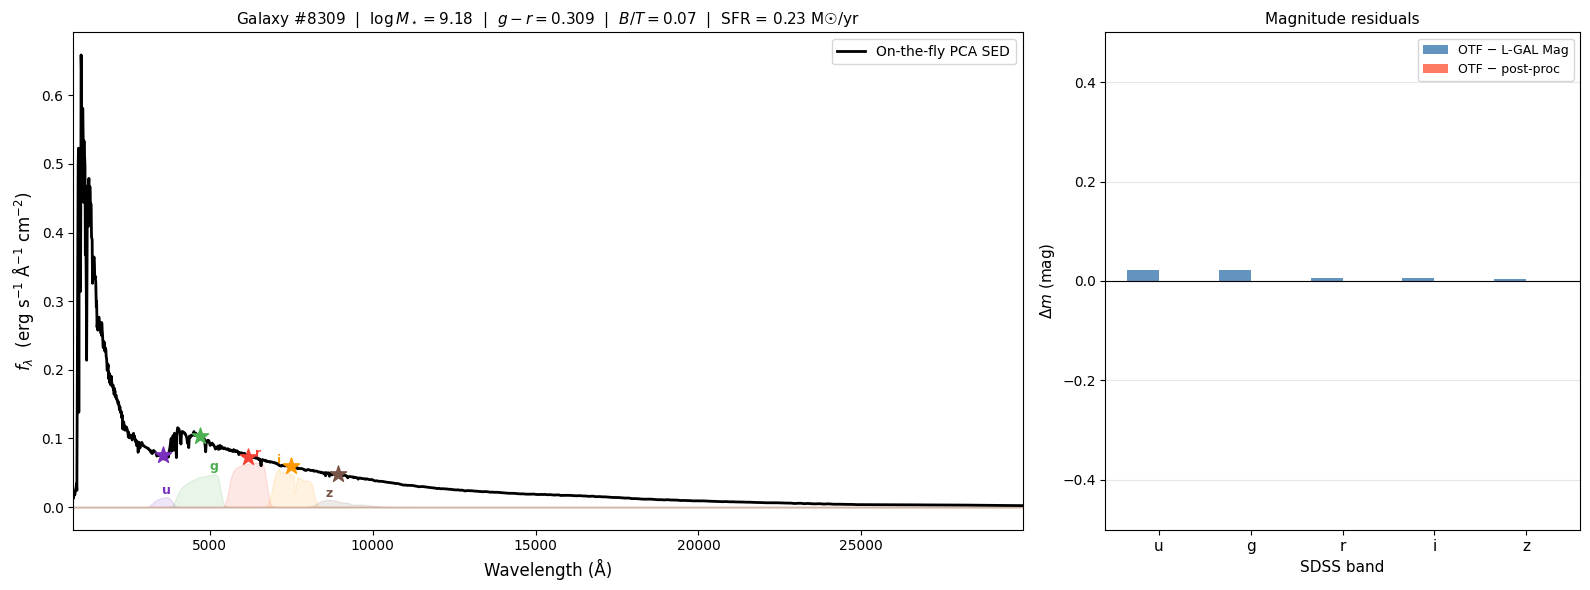

Band       OTF  L-GAL Mag  Δ(OTF-LG) |  post-proc  Δ(OTF-PP)
──────────────────────────────────────────────────────────────
u      -17.397    -17.419     +0.022 |    -17.397    -0.0000
g      -18.228    -18.250     +0.022 |    -18.228    -0.0000
r      -18.537    -18.543     +0.006 |    -18.537    -0.0000
i      -18.697    -18.703     +0.005 |    -18.697    -0.0000
z      -18.831    -18.835     +0.004 |    -18.831    -0.0000


In [15]:
plot_galaxy_sed(galaxy_idx=8309, log_scale=False, show_residuals=True)